Purpose: Incorporate results from newly completed genotypes' maSigPro runs into overall maSigPro results.<br>
Author: Anna Pardo<br>
Date initiated: Dec. 1, 2025

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import json

In [2]:
# load cluster-grouping info so far
cinfo = pd.read_csv("./clusters_ngenes_gt_ztgroup.txt",sep="\t",header="infer")
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [3]:
cinfo["genotype"].unique()

array(['53', 'Eudy', '13', '52', '48', 'G', '19', '46', '56', '45', '18',
       '70', '1AB', '55', '51', '2AB', '37', 'all'], dtype=object)

In [4]:
# load CAM gene annotations
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [5]:
# load TPM data
mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_137/3237519056.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [6]:
# subset to only certain time points (ZT 1,5,9,13,17,21)
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [7]:
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
    sum1 = gtc.groupby("cluster").count().reset_index().rename(columns={"GeneID":"n_genes_"+gt})
    gtcam = cam.merge(gtc)
    camsum = gtcam.groupby("cluster").count().reset_index()[["cluster","GeneID"]].rename(columns={"GeneID":"n_genes_"+gt})
    d = {"clusters":gtc,"CAMgenes":gtcam,"all_summary":sum1,"CAM_summary":camsum}
    return d

In [10]:
# load genotype 36 results
gt36 = load_sum_gt("36")

In [8]:
# load genotype 43 results
gt43 = load_sum_gt("43")

In [9]:
# load genotype 61 results
gt61 = load_sum_gt("61")

In [11]:
allgt = {"36":gt36,"43":gt43,"61":gt61}

In [12]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(c,cpdf,axc,a,tf,log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title("Cluster "+str(c),fontsize=tf)

In [13]:
# rework plottpm similarly
def plottpm_sgt(tpm,c,gt):
    cinfo = allgt[gt]["clusters"]
    cinfo = cinfo[cinfo["cluster"]==c]
    cgenes = list(cinfo["GeneID"].unique())
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    # subset to just one genotype
    pgt = pwide[pwide["genotype"]==gt]
    plong = pd.melt(pgt,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    sg = []
    for i in list(plong["GeneID"]):
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    plong["subgenome"] = sg
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [14]:
# for each of these genotypes: plot cluster expression profiles to determine what group to put them in
## create a function for this
def plot_genotype_clusters(gt):
    fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(30,15))
    plot_profile(1,plottpm_sgt(zttpm,1,gt),(0,0),ax,30,log=False)
    plot_profile(2,plottpm_sgt(zttpm,2,gt),(0,1),ax,30,log=False)
    plot_profile(3,plottpm_sgt(zttpm,3,gt),(0,2),ax,30,log=False)
    plot_profile(4,plottpm_sgt(zttpm,4,gt),(1,0),ax,30,log=False)
    plot_profile(5,plottpm_sgt(zttpm,5,gt),(1,1),ax,30,log=False)
    plot_profile(6,plottpm_sgt(zttpm,6,gt),(1,2),ax,30,log=False)
    plt.savefig("./genotype_profile_plots/profiles_"+gt+".png",dpi=200,bbox_inches="tight")
    plt.savefig("./genotype_profile_plots/profiles_"+gt+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig("./genotype_profile_plots/profiles_"+gt+".svg",dpi=200,bbox_inches="tight")

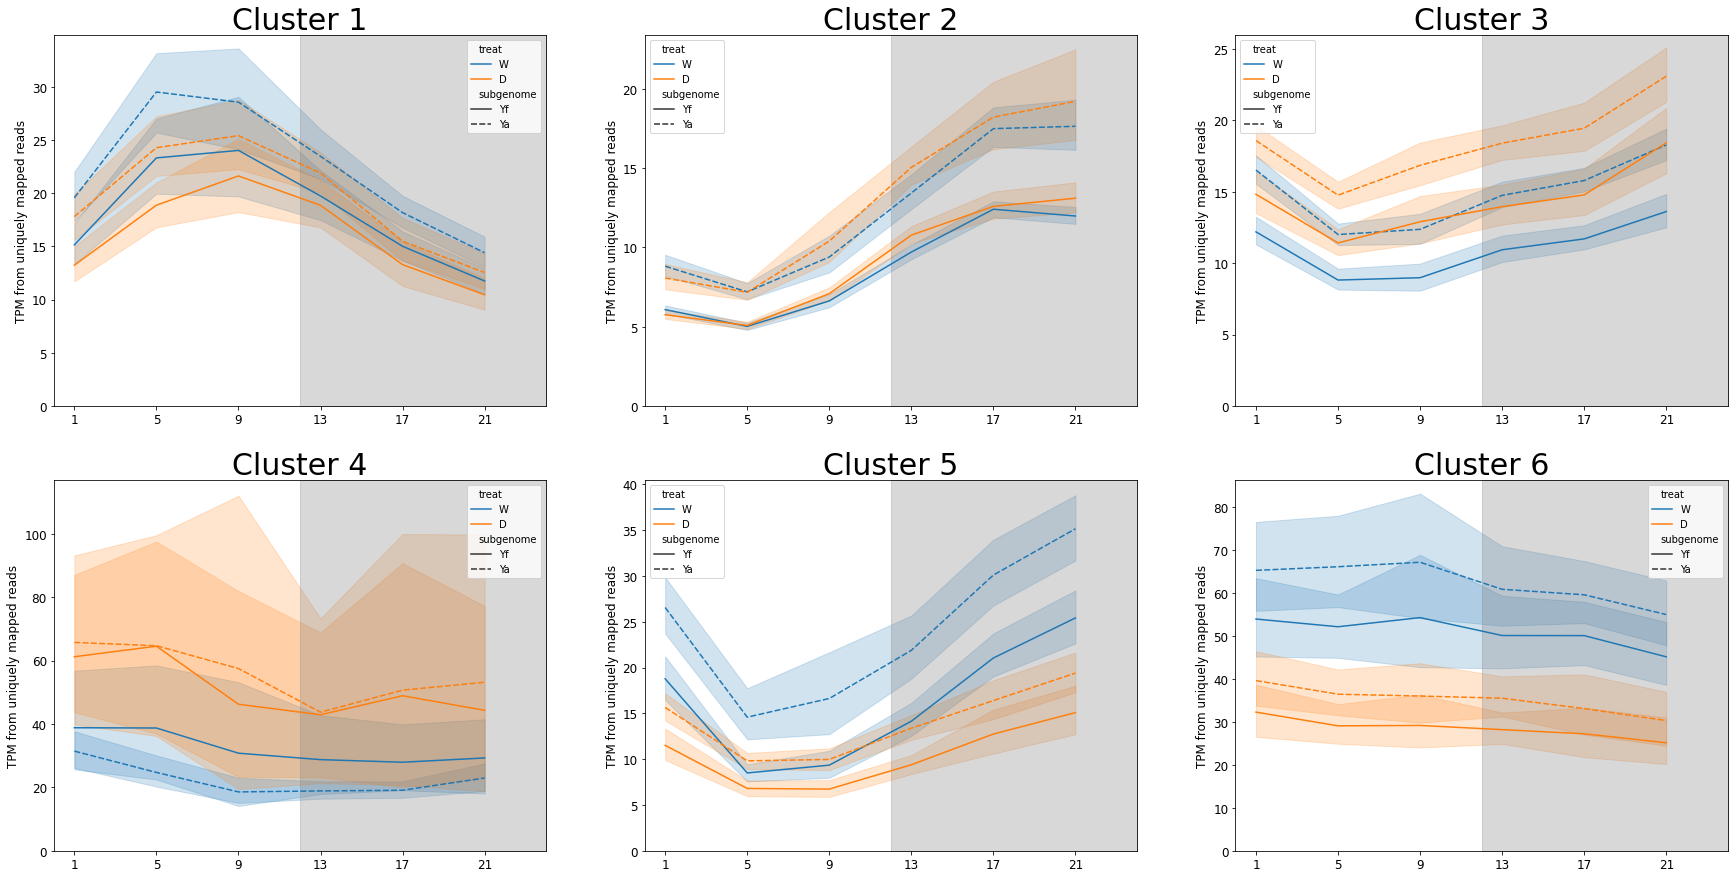

In [20]:
plot_genotype_clusters("36")

ZT peaks for clusters of genotype 36:<br>
1 - ZT5<br>
2 - ZT21<br>
3 - ZT21<br>
4 - ZT5<br>
5 - ZT21<br>
6 - ZT9

In [25]:
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [34]:
# make a dict of the ZT peak information for genotype 36
zt36 = {1:5.0,
       2:21.0,
       3:21.0,
       4:5.0,
       5:21.0,
       6:9.0}

In [35]:
# construct information for genotype 36, to be added to cinfo dataframe
## create a function to do so
def make_genotype_info(gt,ztdict):
    gtdict = allgt[gt]
    #dfdict = {"cluster":[],"genotype":[],"n_CAM_genes":[],"n_all_genes":[],"gtc":[],"ZTpeak":[]}
    
    gtsum = gtdict["all_summary"].rename(columns={"n_genes_"+gt:"n_all_genes"})
    gtcamsum = gtdict["CAM_summary"].rename(columns={"n_genes_"+gt:"n_CAM_genes"})
    gtm = gtsum.merge(gtcamsum,how="left")
    gtm.fillna(value=0,inplace=True)
    gtm["genotype"] = gt
    gtm["gtc"] = gtm["genotype"]+"_"+gtm["cluster"].astype(str)
    gtm["ZTpeak"] = gtm["cluster"].map(ztdict)
    return gtm[["cluster","genotype","n_CAM_genes","n_all_genes","gtc","ZTpeak"]]

In [36]:
make_genotype_info("36",zt36)

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,36,14.0,7553,36_1,5.0
1,2,36,5.0,5361,36_2,21.0
2,3,36,0.0,2518,36_3,21.0
3,4,36,5.0,4124,36_4,5.0
4,5,36,1.0,2488,36_5,21.0
5,6,36,6.0,4135,36_6,9.0


In [37]:
cinfo = pd.concat([cinfo,make_genotype_info("36",zt36)])
cinfo.tail()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
1,2,36,5.0,5361,36_2,21.0
2,3,36,0.0,2518,36_3,21.0
3,4,36,5.0,4124,36_4,5.0
4,5,36,1.0,2488,36_5,21.0
5,6,36,6.0,4135,36_6,9.0


In [49]:
# save cinfo
cinfo.to_csv("./clusters_ngenes_gt_ztgroup_with36.txt",sep="\t",header=True,index=False)

In [50]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [51]:
# pull just metadata from zttpm
md = zttpm[["sample_name","genotype","treat","ZT"]]

In [52]:
# save it
md.to_csv("./metadata_from_TPM_ztsub.txt",sep="\t",header=True,index=False)

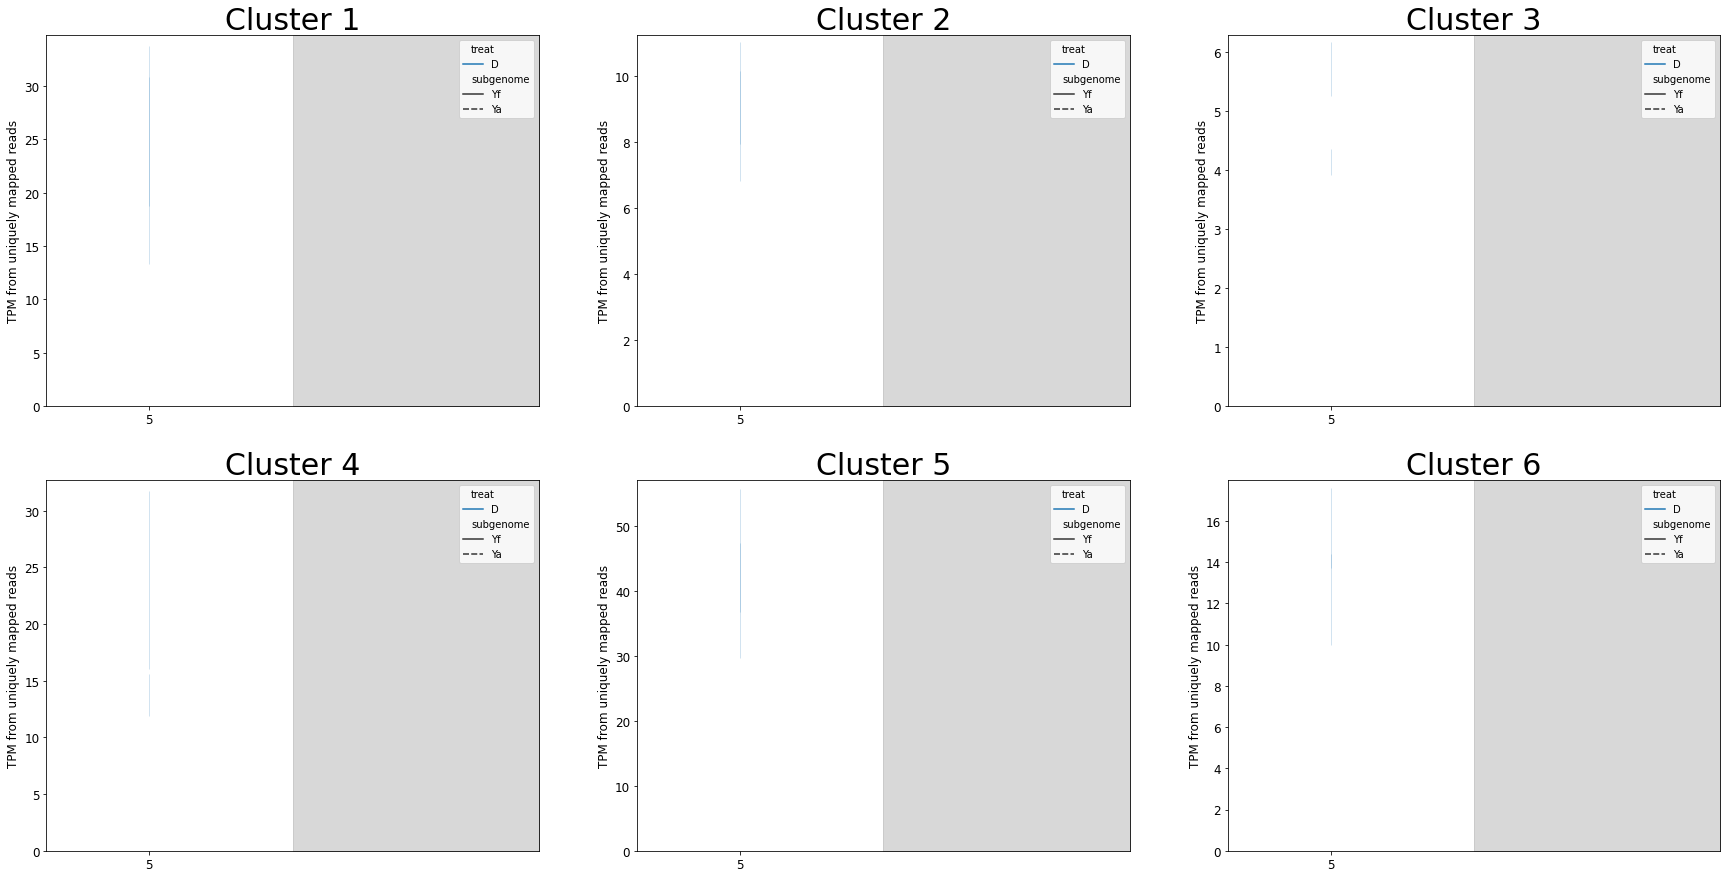

In [21]:
plot_genotype_clusters("43")

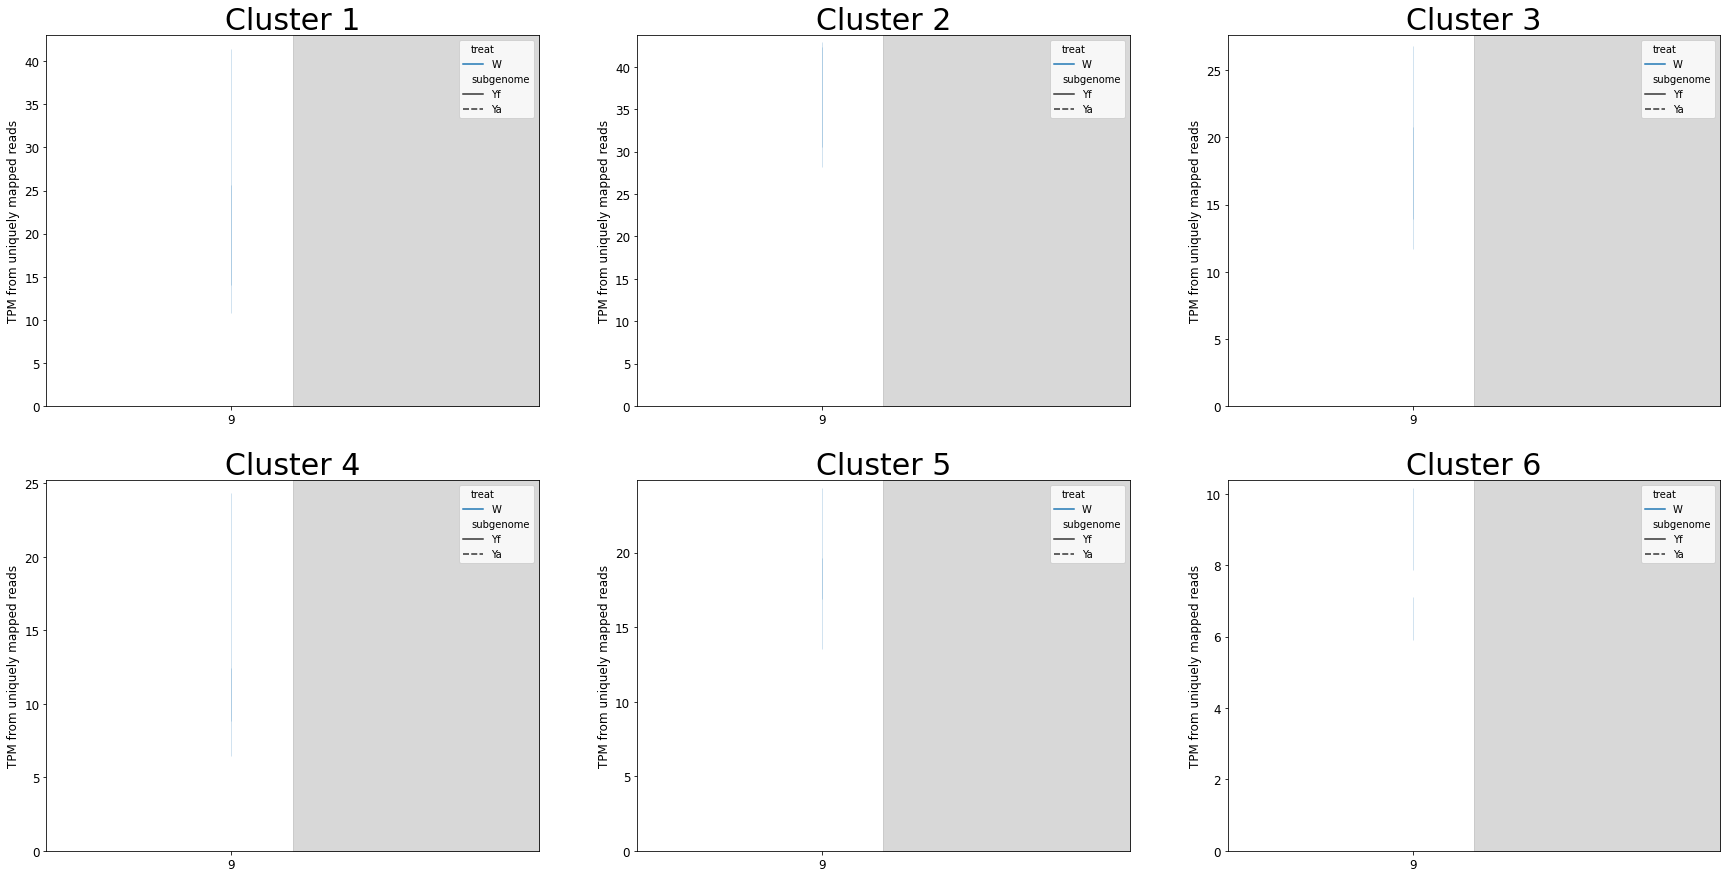

In [24]:
plot_genotype_clusters("61")

In [16]:
dflist = []
for i in range(1,7):
    dflist.append(plottpm_sgt(zttpm,i,"61"))

In [17]:
plot61 = pd.concat(dflist)
plot61.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
1068,SRR10848771,61,W,9.0,YufilH1032761m.g,1.534140,Yf
1078,SRR10848771,61,W,9.0,YufilH1033460m.g,9.157056,Yf
1077,SRR10848771,61,W,9.0,YufilH1033377m.g,1.873782,Yf
1076,SRR10848771,61,W,9.0,YufilH1033302m.g,2.439539,Yf
1075,SRR10848771,61,W,9.0,YufilH1033124m.g,2.402300,Yf


In [18]:
plot61["ZT"].unique()

array([9.])

In [19]:
mdtpm[mdtpm["genotype"]=="61"]["ZT"].unique()

array([9.])

In [20]:
# this seems wrong
## load counts with metadata
mdcounts = pd.read_csv("../counts/Yg_toYgIS_all_correctedmd_countsmatrix.txt",sep="\t",header="infer")
mdcounts.head()

/tmp/ipykernel_137/172163221.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdcounts = pd.read_csv("../counts/Yg_toYgIS_all_correctedmd_countsmatrix.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g,Total_Reads
0,Y1,18,1.0,W,1.0,gloriosa,745,50,0,536,...,42,26,14,196,10,34,173,0,0,12458673
1,Y10,2AB,1.5,W,3.0,gloriosa,176,8,0,93,...,3,57,12,35,0,8,63,0,0,2479905
2,Y100,2AB,6.5,W,23.0,gloriosa,472,26,0,246,...,7,179,41,80,12,17,297,0,3,6344543
3,Y101,2AB,1.0,D,1.0,gloriosa,856,48,0,225,...,5,342,40,107,13,30,80,0,2,8914664
4,Y103,2AB,1.0,D,1.0,gloriosa,488,43,0,222,...,4,333,28,78,5,28,77,0,2,8074213


In [21]:
mdcounts[mdcounts["genotype"]=="61"]["ZT"].unique()

array([9.])

In [22]:
mdcounts[mdcounts["genotype"]=="43"]["ZT"].unique()

array([5.])

In [23]:
mdcounts["ZT"].unique()

array([ 1.,  3., 23., 21.,  5.,  7.,  9., 13., 11., 15., 17., 19.])

In [24]:
mdcounts.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g,Total_Reads
0,Y1,18,1.0,W,1.0,gloriosa,745,50,0,536,...,42,26,14,196,10,34,173,0,0,12458673
1,Y10,2AB,1.5,W,3.0,gloriosa,176,8,0,93,...,3,57,12,35,0,8,63,0,0,2479905
2,Y100,2AB,6.5,W,23.0,gloriosa,472,26,0,246,...,7,179,41,80,12,17,297,0,3,6344543
3,Y101,2AB,1.0,D,1.0,gloriosa,856,48,0,225,...,5,342,40,107,13,30,80,0,2,8914664
4,Y103,2AB,1.0,D,1.0,gloriosa,488,43,0,222,...,4,333,28,78,5,28,77,0,2,8074213


In [25]:
mdcounts["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', 36, 18,
       13, '13', 45, '45', '52', '43', 52, '37', '48', '55', '70', '61',
       51, 70, 55, 61, 46, 43, 37, 53, 48, 16, 19, 6, 12, 20, 50],
      dtype=object)

In [26]:
zttpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', 36, 13,
       '13', 18, 45, '45', '52', '43', 52, '37', '48', '55', '70', '61',
       51, 70, 55, 61, 46, 43, 37, 53, 48, 16, 19, 6, 12, 20, 50],
      dtype=object)

In [27]:
# fix genotype column in mdcounts & zttpm
mdcounts["genotype"] = mdcounts["genotype"].astype(str)
mdcounts["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [28]:
zttpm["genotype"] = zttpm["genotype"].astype(str)
zttpm["genotype"].unique()

/tmp/ipykernel_137/2117932980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zttpm["genotype"] = zttpm["genotype"].astype(str)


array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

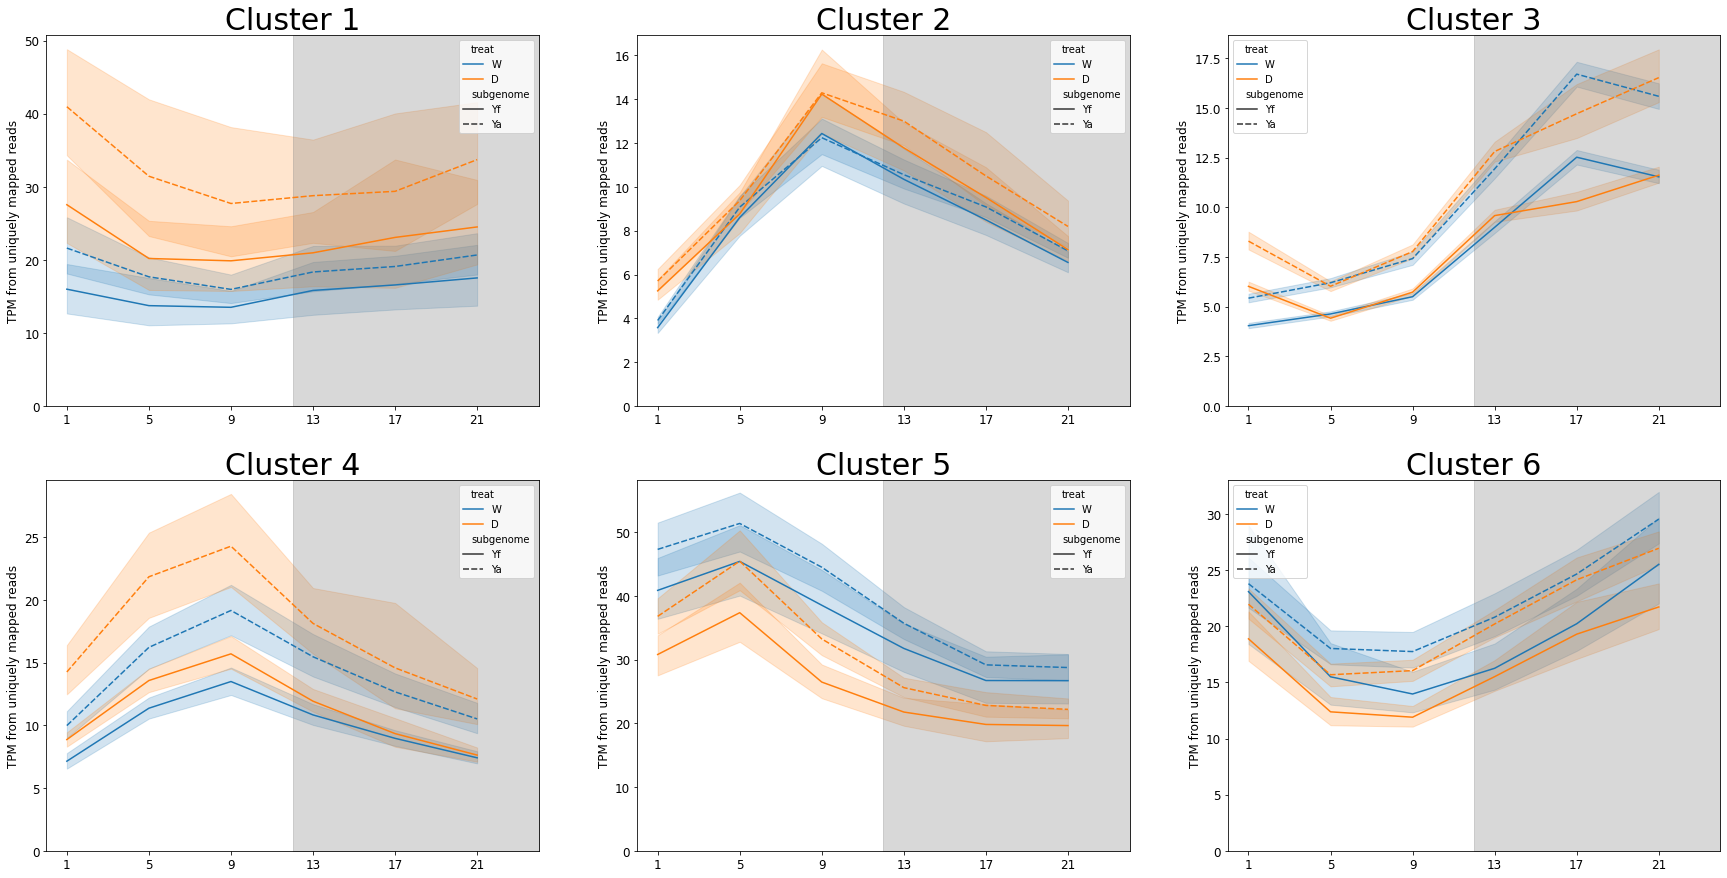

In [29]:
plot_genotype_clusters("43")

In [32]:
# make ztdict for genotype 43
zt43 = {
    1:1.0,
    2:9.0,
    3:17.0,
    4:9.0,
    5:5.0,
    6:21.0
}

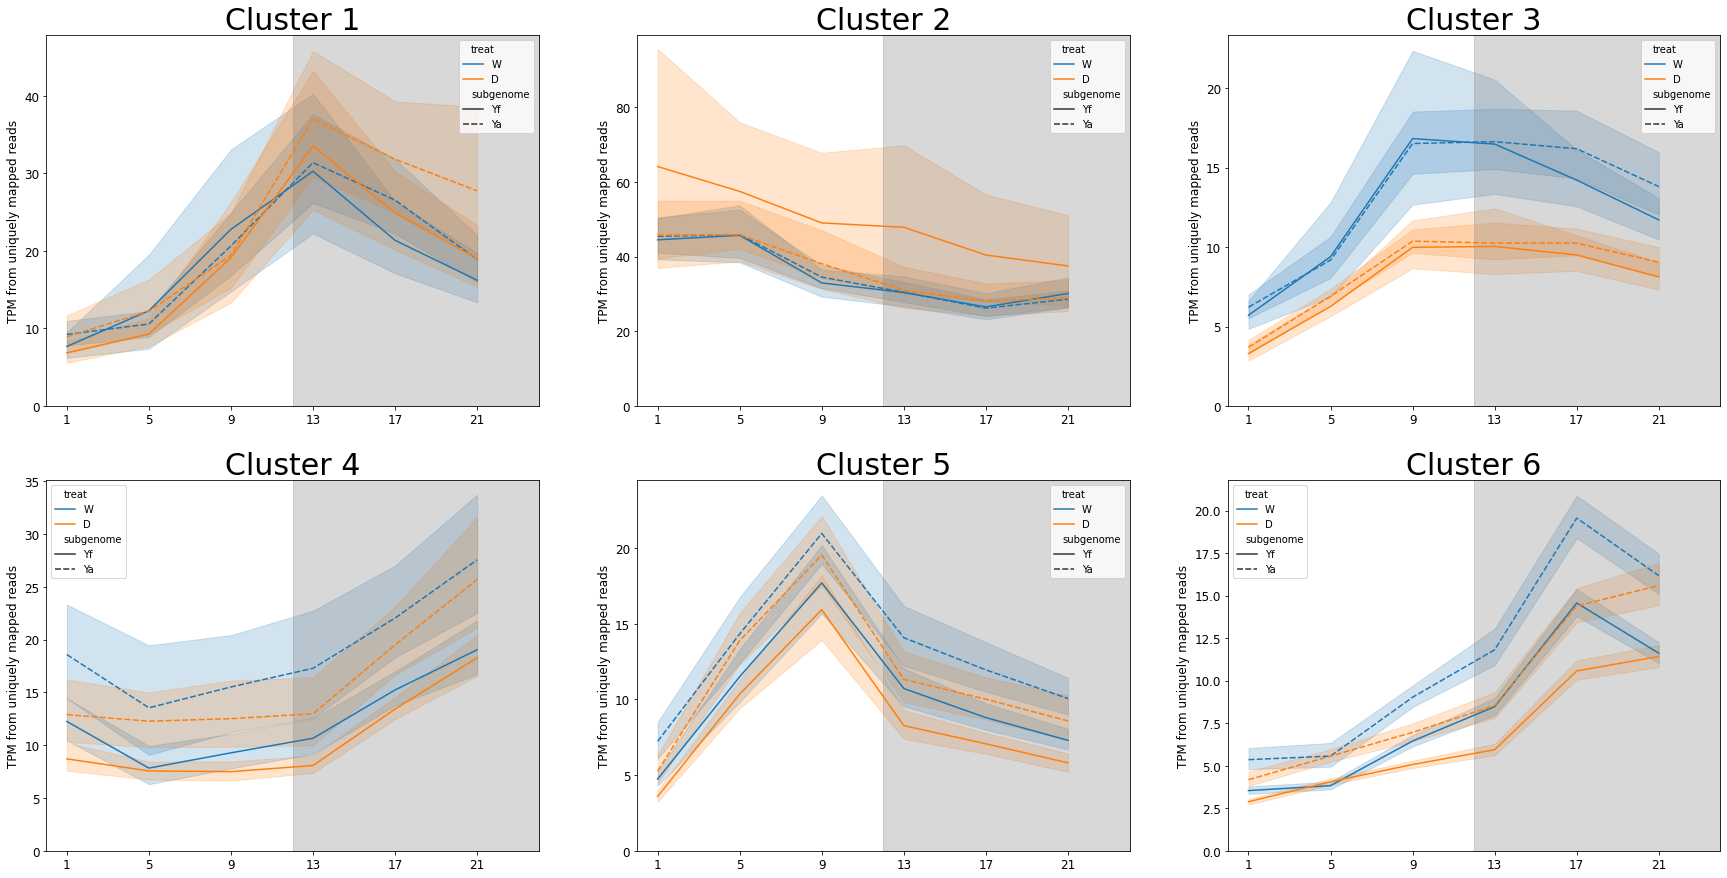

In [30]:
plot_genotype_clusters("61")

In [33]:
# make ztdict for 61
zt61 = {
    1:13.0,
    2:5.0,
    3:9.0,
    4:21.0,
    5:9.0,
    6:17.0
}

In [38]:
# add 43 & 61 to the overall genotype information
cinfo = pd.concat([cinfo,make_genotype_info("61",zt61),make_genotype_info("43",zt43)])
cinfo.tail()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
1,2,43,3.0,7942,43_2,9.0
2,3,43,6.0,11070,43_3,17.0
3,4,43,10.0,5731,43_4,9.0
4,5,43,9.0,6294,43_5,5.0
5,6,43,7.0,3975,43_6,21.0


In [39]:
# save cinfo
cinfo.to_csv("./clusters_ngenes_gt_ztgroup_with36-61-43.txt",sep="\t",header=True,index=False)

In [40]:
list(cinfo["genotype"].unique())

['53',
 'Eudy',
 '13',
 '52',
 '48',
 'G',
 '19',
 '46',
 '56',
 '45',
 '18',
 '70',
 '1AB',
 '55',
 '51',
 '2AB',
 '37',
 'all',
 '36',
 '61',
 '43']